In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pyranges as pr
import pyBigWig
import re
from matplotlib.cm import get_cmap
import matplotlib.colors as mcolors


In [3]:
def average_sample_repeats(merged_pyranges):
    df = merged_pyranges.copy()

    sample_groups = {}
    for col in df.columns[7:]:  
        base_name = re.sub(r'_\d+$', '', col)
        if base_name not in sample_groups:
            sample_groups[base_name] = []
        sample_groups[base_name].append(col)

    averaged_df = df[['Chromosome', 'Start', 'End', 'Cluster','peak_center', 'start_300', 'end_300']].copy()
    for base_name, cols in sample_groups.items():
        averaged_df[base_name + "_avg"] = df[cols].mean(axis=1)
    return pr.PyRanges(averaged_df)

In [4]:
def plot_density_clean(df, combinations):

    base = get_cmap('viridis')
    colors = base(np.linspace(0.1, 1, 256)) 
    colors[0] = [1, 1, 1, 1]
    white_viridis = mcolors.ListedColormap(colors)    

    fig, axes = plt.subplots(1, len(combinations), figsize=(5 * len(combinations), 5), facecolor='white')

    if len(combinations) == 1:
        axes = [axes]

    for ax, (x_col, y_col) in zip(axes, combinations):
        data = df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()

        h = ax.hist2d(
            data[x_col], data[y_col],
            bins=150,
            cmap=white_viridis,
            vmin=0,
            vmax = 80,
            rasterized=True
        )
        
        x_min, x_max = data[x_col].min(), data[x_col].max()
        y_min, y_max = data[y_col].min(), data[y_col].max()
        
        x_pad = (x_max - x_min) * 0.05
        y_pad = (y_max - y_min) * 0.05
        
        ax.set_xlim(x_min - x_pad, x_max + x_pad)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)

    
        cbar = plt.colorbar(h[3], ax=ax)

        ax.set_facecolor("white")
        ax.set_xlabel(x_col, fontsize=14)
        ax.set_ylabel(y_col, fontsize=14)

    plt.tight_layout()
    return fig, axes

In [5]:
def extract_signal(bigwig_file, peaks, flank=1000):
    bw = pyBigWig.open(bigwig_file)
    signals = []

    for _, row in peaks.iterrows():
        chrom, center = row["Chromosome"], row["peak_center"]
        start, end = center - flank, center + flank

        if chrom not in bw.chroms():
            print(f"Skipping {chrom}: not found in BigWig.")
            signals.append(np.full((2 * flank,), np.nan))
            continue
        
        chrom_length = bw.chroms(chrom)
        if start < 0 or end > chrom_length:
            print(f"Skipping {chrom} {start}-{end}: out of bounds.")
            signals.append(np.full((2 * flank,), np.nan))
            continue

        try:
            signal = np.nan_to_num(bw.values(chrom, start, end))
            signals.append(signal)
        except Exception as e:
            print(f"Error extracting {chrom} {start}-{end}: {e}")
            signals.append(np.full((2 * flank,), np.nan))

    bw.close()
    return np.array(signals, dtype=np.float32)

In [6]:
def plot_signal_heatmaps(samples, bw_files, dominated_peaks,
                                    vmax_values={}, sample_colors={}, sample_labels={}, save_as=None):
    
    colormap_options = {
        "ar": sns.blend_palette(["white", "#6DB1AB"], as_cmap=True),
        "gr": sns.blend_palette(["white", "#195E90"], as_cmap=True),
        "pr": sns.blend_palette(["white", "#5A4A91"], as_cmap=True)
    }

    # Extract signal
    signals = {key: extract_signal(bw_files[key], pd.concat(dominated_peaks[key])) for key in samples}

    sorted_indices = {}
    for key in samples:
        peak_lengths = [len(df) for df in dominated_peaks[key]]
        sections = np.split(np.arange(sum(peak_lengths)), np.cumsum(peak_lengths[:-1]))
        sorted_sections = [np.argsort(-signals[key][section].mean(axis=1)) for section in sections]
        sorted_indices[key] = np.concatenate(
            [sorted_sections[i] + sum(peak_lengths[:i]) for i in range(len(sections))]
        )

    num_samples = len(samples)

    fig, axes = plt.subplots(
        3, num_samples, figsize=(num_samples * 3.5, 12),
        gridspec_kw={"height_ratios": [2, 10, 0.3]}
    )

    section_colors = ["#6DB1AB", "#195E90", "#5A4A91"]

    for i, sample in enumerate(samples):
        color_key = sample_colors[sample]
        cmap = colormap_options[color_key]
        vmax = vmax_values.get(sample, None)

        # Average Signal
        ax_signal = axes[0, i]
        peak_lengths = [len(df) for df in dominated_peaks[sample]]

        has_valid_section = False
        max_y = 0

        for j, df in enumerate(dominated_peaks[sample]):
            if df.empty:
                print(f"Skipping empty section {j+1} for sample {sample}")
                continue

            section_signal = extract_signal(bw_files[sample], df)
            if section_signal.size == 0:
                print(f"Skipping section {j+1} for sample {sample} (no extracted signal)")
                continue

            mean_signal = np.nanmean(section_signal, axis=0)
            x = np.arange(-1000, 1000)

            ax_signal.plot(x, mean_signal, label=f"Section {j + 1}", color=section_colors[j], linewidth=1.5)
            max_y = max(max_y, np.nanmax(mean_signal))
            has_valid_section = True

        ax_signal.axvline(0, color="black", linestyle="--", linewidth=1)
        ax_signal.set_xticks([-1000, 0, 1000])
        ax_signal.set_xticklabels(["-1000", "0", "1000"])

        if has_valid_section:
            ymax = np.ceil(max_y) if np.isfinite(max_y) else 1
            ax_signal.set_ylim(0, ymax)

            num_ticks = min(5, int(ymax) + 1)
            yticks = np.linspace(0, ymax, num_ticks) if ymax > 0 else [0]
            ax_signal.set_yticks(yticks)
            ax_signal.set_yticklabels([f"{y:.0f}" for y in yticks], fontsize=8)

            ax_signal.set_title(sample_labels.get(sample, sample), fontsize=12)
            ax_signal.legend(fontsize=8)
        else:
            ax_signal.set_xticks([])
            ax_signal.set_yticks([])
            ax_signal.set_title(sample_labels.get(sample, sample), fontsize=12)

        # Heatmap
        ax_heatmap = axes[1, i]
        im = ax_heatmap.imshow(signals[sample][sorted_indices[sample]], aspect="auto", cmap=cmap, vmax=vmax)

        ax_heatmap.set_yticks([])
        ax_heatmap.set_xticks([0, signals[sample].shape[1] // 2, signals[sample].shape[1] - 1])
        ax_heatmap.set_xticklabels(["-1000", "0", "1000"], fontsize=10)

        for peak_len in np.cumsum(peak_lengths[:-1]):
            ax_heatmap.axhline(y=peak_len, color="black", linestyle="dashed", linewidth=1)

        # Colorbar
        cbar_ax = axes[2, i]
        cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", fraction=0.05, pad=0.1)
        cbar.outline.set_visible(False)
        cbar.ax.tick_params(size=0, labelsize=8)

    plt.tight_layout(h_pad=2)

    if save_as:
        plt.savefig(save_as, dpi=300, bbox_inches='tight')

    plt.show()


In [7]:
# For HepG2
def add_peak_center_and_range_new(df):
    df = df.copy()  
    df.insert(3, "peak_center", ((df["Start"] + df["End"]) / 2).astype(int))
    df.insert(4, "start_300", df["peak_center"] - 300)
    df.insert(5, "end_300", df["peak_center"] + 300)

    return df


In [8]:
# For HepG2
def average_sample_repeats_new(df):
    df = df.copy()

    signal_columns = df.columns[12:]

    sample_groups = {}
    for col in signal_columns:
        base_name = re.sub(r'\d+$', '', col)
        if base_name not in sample_groups:
            sample_groups[base_name] = []
        sample_groups[base_name].append(col)

    # Averaging
    averaged_df = df.iloc[:, :12].copy() 
    for base_name, cols in sample_groups.items():
        averaged_df[f"{base_name}_avg"] = df[cols].mean(axis=1)

    return pr.PyRanges(averaged_df)


# NMuMG

In [9]:
NMu_signal = pd.read_parquet('data/NMuMG_Clustered_Peaks.parquet')

In [10]:
NMu_Pcorr = NMu_signal.iloc[: , 7:].corr(method="pearson")

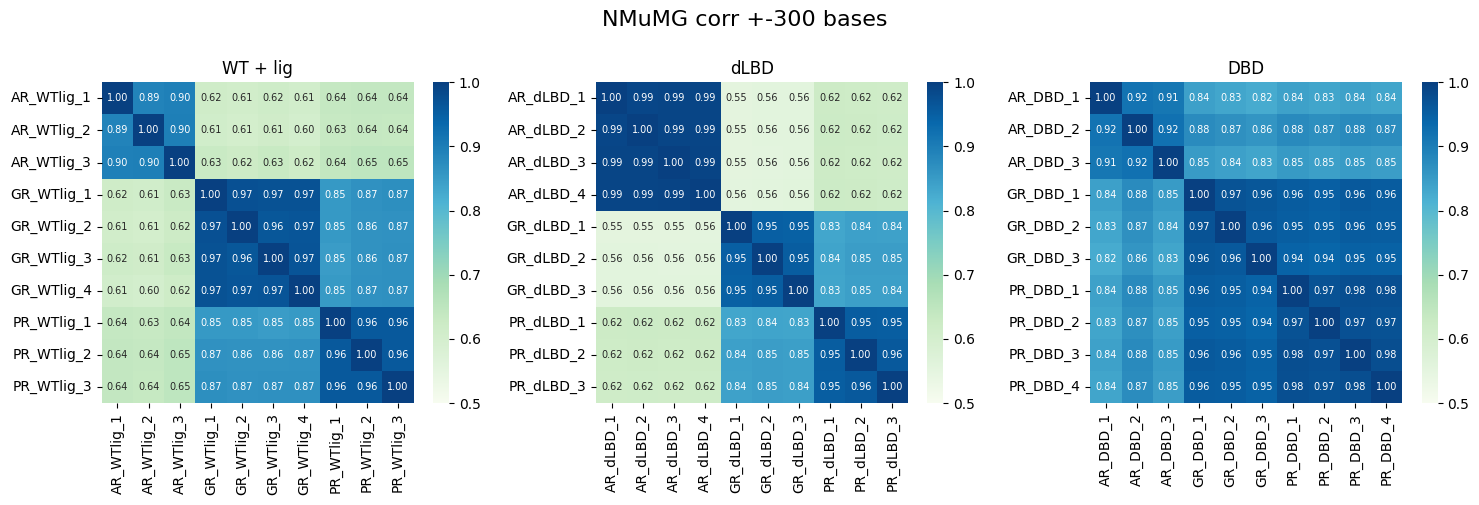

In [11]:
def plot_correlation_heatmaps(WT_lig, dLBD, DBD): 
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    sns.heatmap(WT_lig, cmap='GnBu', vmin=.5, vmax=1, ax=axes[0], annot=True, annot_kws={"size": 7}, fmt=".2f") 
    axes[0].set_title('WT + lig')

    sns.heatmap(dLBD, cmap='GnBu', vmin=.5, vmax=1, ax=axes[1], annot=True, annot_kws={"size": 7}, fmt=".2f") 
    axes[1].set_title('dLBD')

    sns.heatmap(DBD, cmap='GnBu', vmin=.5, vmax=1, ax=axes[2], annot=True, annot_kws={"size": 7}, fmt=".2f") 
    axes[2].set_title('DBD')

    fig.suptitle('NMuMG corr +-300 bases', fontsize=16, y=1)

    plt.tight_layout()

plot_correlation_heatmaps(NMu_Pcorr.filter(regex=('WTlig'), axis=1).filter(regex=('WTlig'), axis=0),
                          NMu_Pcorr.filter(regex='dLBD', axis=1).filter(regex='dLBD', axis=0),
                         NMu_Pcorr.filter(regex='DBD', axis=1).filter(regex='DBD', axis=0)
                         )
    
plt.show()


In [12]:
NMu_av = average_sample_repeats(NMu_signal)

In [18]:
n_combinations = [
    ('AR_WTlig_avg', 'GR_WTlig_avg'), ('AR_WTlig_avg', 'PR_WTlig_avg'), ('GR_WTlig_avg', 'PR_WTlig_avg'),
    ('AR_dLBD_avg', 'GR_dLBD_avg'), ('AR_dLBD_avg', 'PR_dLBD_avg'), ('GR_dLBD_avg', 'PR_dLBD_avg'),
    ('AR_DBD_avg', 'GR_DBD_avg')
]

In [19]:
# removing outliers for better visualization of scatter plots
NMu_signal_p998 = NMu_signal.copy()
NMu_signal_p998.iloc[:, 7:] = NMu_signal_p998.iloc[:, 7:][NMu_signal_p998.iloc[:, 7:].le(NMu_signal_p998.iloc[:, 7:].quantile(0.998))]

In [20]:
NMu_av_998 = average_sample_repeats(NMu_signal_p998)

/tmp/ipykernel_1516660/3296149415.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  base = get_cmap('viridis')


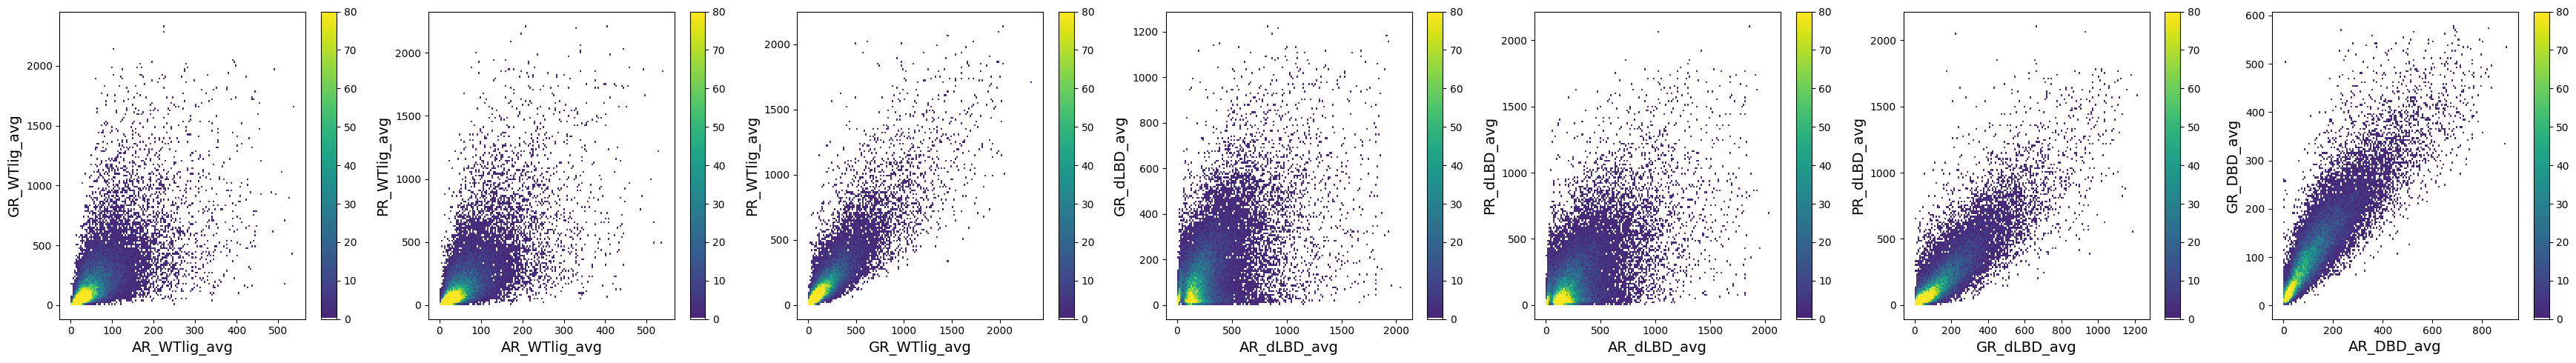

In [21]:
fig, axes = plot_density_clean(NMu_av_998.df, n_combinations)
plt.show()

In [22]:
# z score (data - data.mean()) / data.std
NMu_zscore = NMu_av.df.copy()
NMu_zscore.iloc[:, 7:] = (NMu_zscore.iloc[:, 7:] - NMu_zscore.iloc[:, 7:].mean()) / NMu_zscore.iloc[:, 7:].std()

In [23]:
receptors = ['AR', 'GR', 'PR']
conditions = ['WTlig', 'dLBD', 'DBD']

# Generate all dominated combinations
dominated_sets = {}

for cond in conditions:
    for dom in receptors:
        others = [r for r in receptors if r != dom]
        dom_col = f"{dom}_{cond}_avg"
        oth1_col = f"{others[0]}_{cond}_avg"
        oth2_col = f"{others[1]}_{cond}_avg"
        
        df_filtered = NMu_zscore[
            (NMu_zscore[dom_col] >= 2.5) &
            (NMu_zscore[oth1_col] <= 1.5) &
            (NMu_zscore[oth2_col] <= 1.5)
        ]
        
        key = f"{cond}_{dom}_dominated"
        dominated_sets[key] = df_filtered


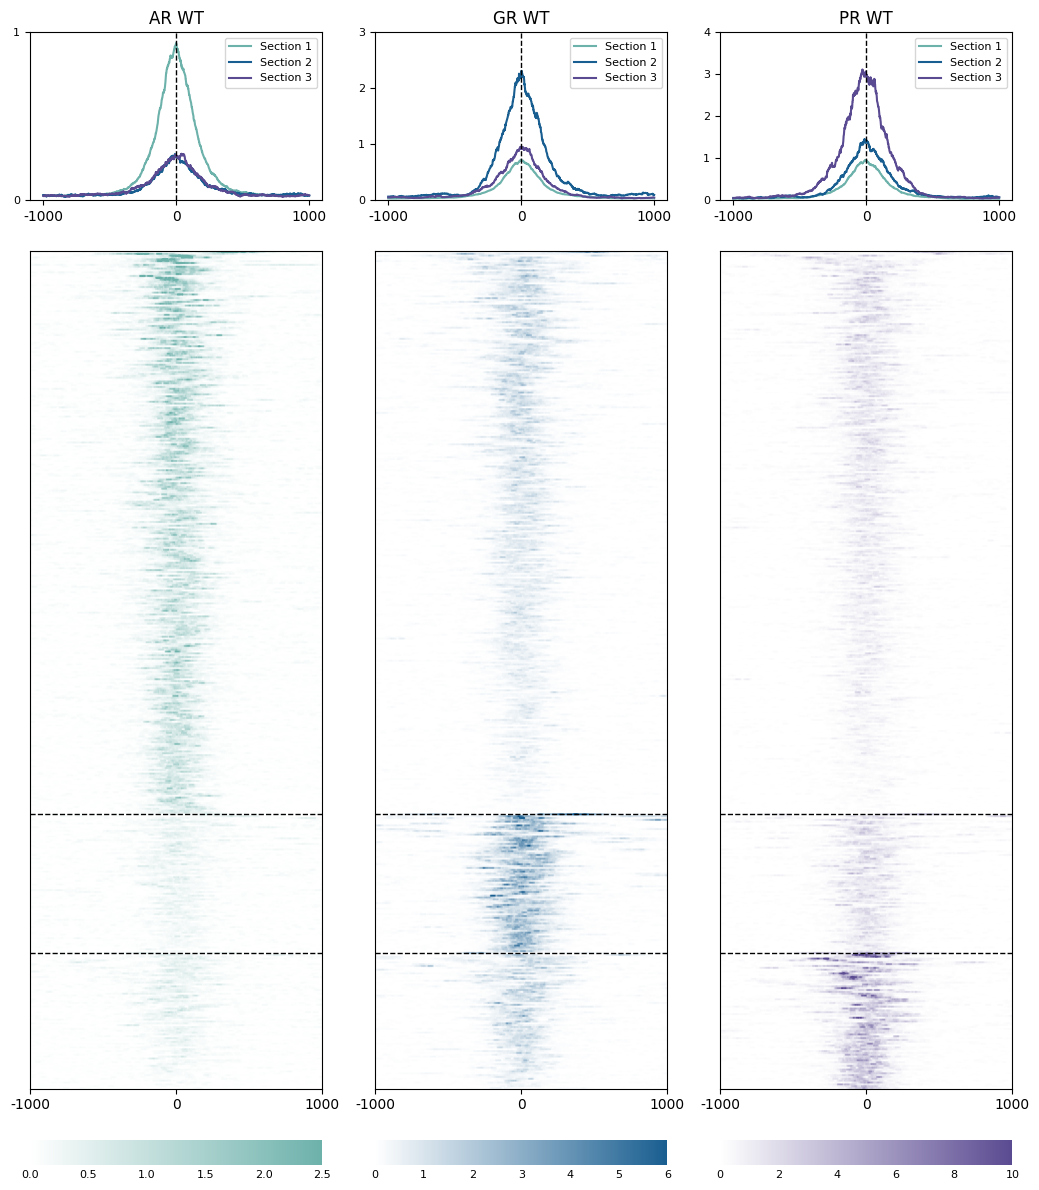

In [24]:
# Build dominated_peaks dictionary
dominated_peaks = {
    tf: [
        dominated_sets["WTlig_AR_dominated"],
        dominated_sets["WTlig_GR_dominated"],
        dominated_sets["WTlig_PR_dominated"]
    ]
    for tf in receptors
}

samples = ['AR', 'GR', 'PR']
bw_files = {
    'AR': 'data/AverageBw/mAR_WT_lig_averaged.bw',
    'GR': 'data/AverageBw/hGR_WT_lig_averaged.bw',
    'PR': 'data/AverageBw/hPR_WT_lig_averaged.bw'
}

sample_colors = {
    'AR': 'ar', 
    'GR': 'gr',
    'PR': 'pr'
}
vmax_values = {
    'AR': 2.5,
    'GR': 6,
    'PR': 10
}
sample_labels = {
    'AR': 'AR WT',
    'GR': 'GR WT',
    'PR': 'PR WT'
}

plot_signal_heatmaps(
    samples=samples,
    bw_files=bw_files,
    dominated_peaks=dominated_peaks,
    vmax_values=vmax_values,
    sample_colors=sample_colors,
    sample_labels=sample_labels,
)


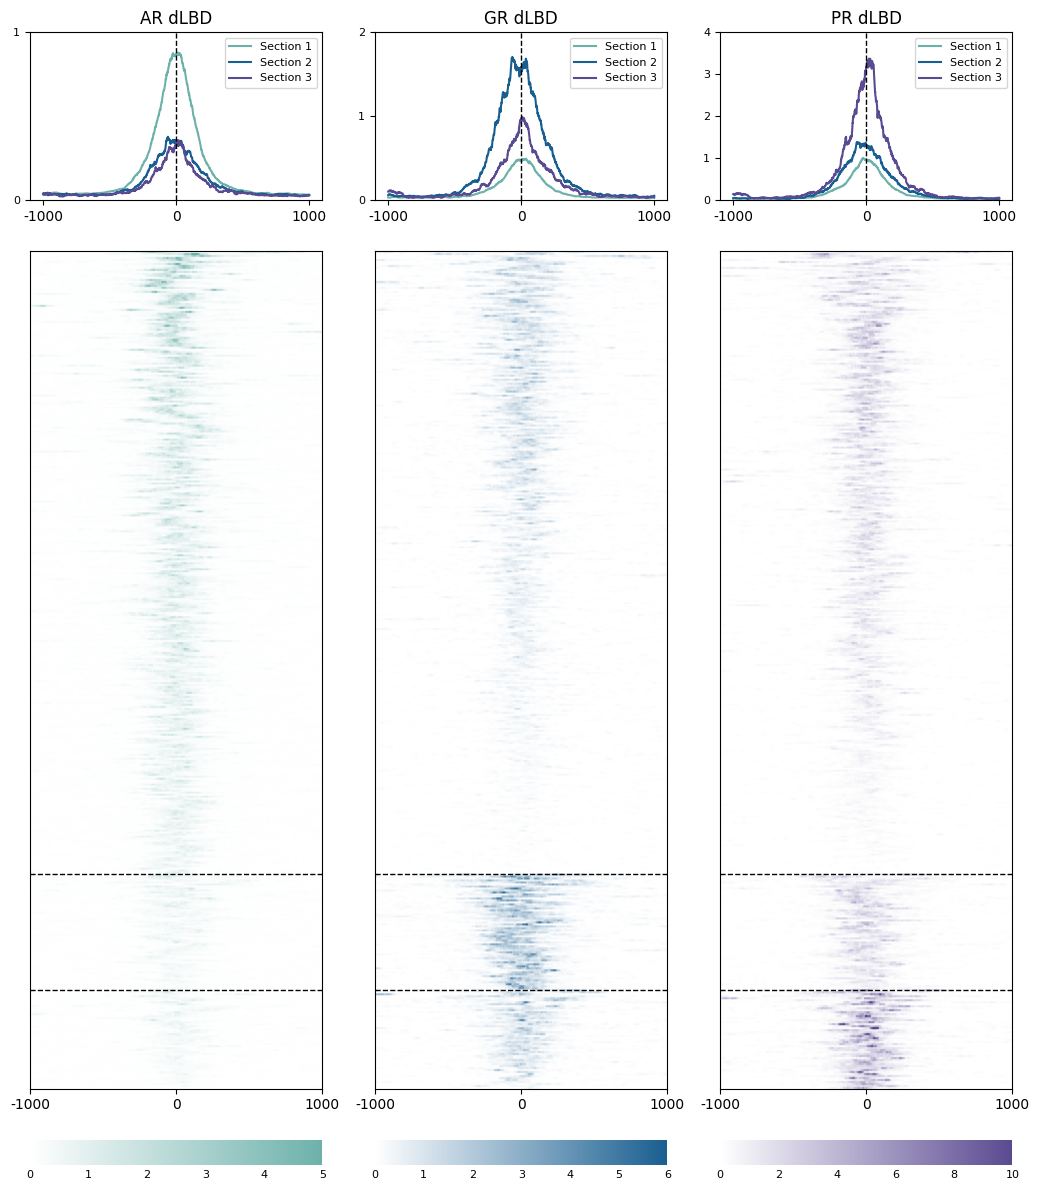

In [25]:
dominated_peaks = {
    tf: [
        dominated_sets["dLBD_AR_dominated"],
        dominated_sets["dLBD_GR_dominated"],
        dominated_sets["dLBD_PR_dominated"]
    ]
    for tf in receptors
}

samples = ['AR', 'GR', 'PR']
bw_files = {
    "AR": 'data/AverageBw/NMuMG_mAR_dLBD_averaged.bw',
    "GR": 'data/AverageBw/hGR_dLBD_averaged.bw',
    "PR": 'data/AverageBw/hPR_del_LBD_averaged.bw'
}
sample_colors = {
    'AR': 'ar', 
    'GR': 'gr',
    'PR': 'pr'
}
vmax_values = {
    'AR': 5,
    'GR': 6,
    'PR': 10
}
sample_labels = {
    'AR': 'AR dLBD',
    'GR': 'GR dLBD',
    'PR': 'PR dLBD'
}

plot_signal_heatmaps(
    samples=samples,
    bw_files=bw_files,
    dominated_peaks=dominated_peaks,
    vmax_values=vmax_values,
    sample_colors=sample_colors,
    sample_labels=sample_labels,

)
